# <h1><center>Lógica Computacional 2024/2025 - TP2</center></h1>

 **Grupo 6**
 * Cláudia Faria, a105531
 * Patrícia Bastos, a102502

In [ ]:
!pip install pysmt
!pysmt-install --z3

from z3 import *
import random

## **Exercício 1**

### Enunciado

Considere a descrição da cifra A5/1.
Pretende-se

a) Definir e codificar, em Z3 e usando o tipo BitVec para modelar a informação, uma FSM que descreva o gerador de chaves.

b) Considere as seguintes eventuais propriedades de erro:
*   ocorrência de um “burst”  0^t (t zeros) que ocorre em   2^t passos ou menos.
*   ocorrência de um “burst” de tamanho t que repete um “burst” anterior no mesmo output em 2^(t/2)  passos ou menos.
  
  Tente codificar estas propriedades e verificar se são acessíveis a partir de um estado inicial aleatoriamente gerado.

### Resolução

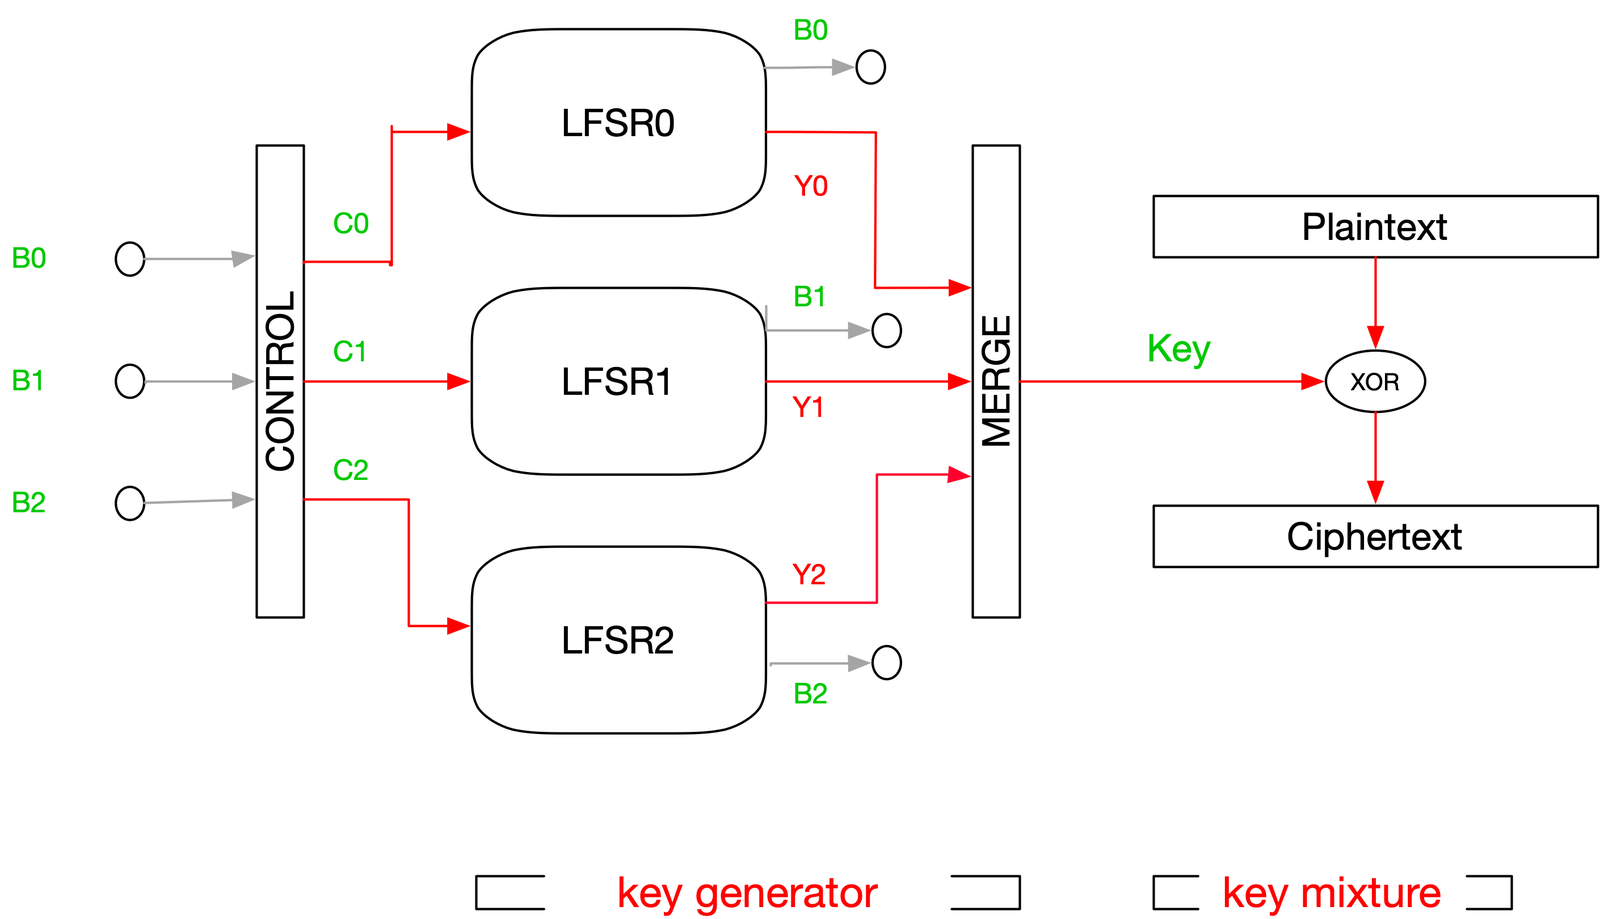

Começamos por definir as seguintes funções:

*   Função ***declare(i)***, que declara o estado do sistema (os 3 LFSR, a key e a posição do último bit colocado na key) em cada instante i;
*   Função ***init(state)***, que gera estados iniciais do sistema com valores aleatórios para cada LFSR;
*   Função ***majority (a, b, c)*** que retorna o bit majoritário entre três bits dados;
*   Função ***proximo_estado(s)***, que calcula o próximo estado do sistema a partir do estado atual;
*   Função ***trans(curr, prox)***, que define a transição entre o estado atual e o próximo estado.

A função *proximo_estado* calcula o *clocking bit* de cada LSFR (no LFSR 0, é o bit de índice 8 e, nos LFSRs 1 e 2, é o bit de índice 10). A partir destes 3 bits, chama a função majority e calcula o *bit majoritário*.

A seguir, a função atualiza cada LSFR. Na cifra A5/1, cada LSFR é deslocado apenas se o seu *bit de controlo* é o *bit majoritário*, bit que calculamos anteriormente. Se o seu *bit de controlo* for diferente, então não é deslocado.

Posteriormente, construímos o novo bit através da operação *merge*. Neste caso, calculamos o *XOR* dos bits mais significativos de cada LSFR.

No final, atualizamos a posição atual no vetor dos *Key Bits* e atualizamos o próprio vetor.


In [ ]:
def declare(i):
    return {
        'LFSR_0': BitVec(f'LFSR_0_{i}', 19),
        'LFSR_1': BitVec(f'LFSR_1_{i}', 22),
        'LFSR_2': BitVec(f'LFSR_2_{i}', 23),
        'keys': BitVec(f'keys_{i}', 64),  # Vetor de 64 bits
        'keys_pos': BitVec(f'keys_pos_{i}', 7)  # Posição atual no vetor (0-63), representada por 7 bits
    }

def init(state):
    z0 = random.getrandbits(19)
    z1 = random.getrandbits(22)
    z2 = random.getrandbits(23)

    return And(
        state['LFSR_0'] == BitVecVal(z0, 19),
        state['LFSR_1'] == BitVecVal(z1, 22),
        state['LFSR_2'] == BitVecVal(z2, 23),
        state['keys'] == BitVecVal(0, 64),  # Inicializado com zero
        state['keys_pos'] == BitVecVal(0, 7)  # Posição inicializada com zero
    )

def majority(a, b, c):
    return (a & b) | (b & c) | (c & a)

def proximo_estado(s):
    c0 = Extract(8, 8, s['LFSR_0'])
    c1 = Extract(10, 10, s['LFSR_1'])
    c2 = Extract(10, 10, s['LFSR_2'])

    maj = majority(c0, c1, c2)

    # Desloca os LFSR e atualiza usando uma função XOR
    updated_LFSR_0 = If(c0 == maj,
                Concat(Extract(17, 0, s['LFSR_0']),
                       Extract(18, 18, s['LFSR_0']) ^ Extract(17, 17, s['LFSR_0']) ^
                       Extract(16, 16, s['LFSR_0']) ^ Extract(13, 13, s['LFSR_0'])),
                s['LFSR_0'])

    updated_LFSR_1 = If(c1 == maj,
                Concat(Extract(20, 0, s['LFSR_1']),
                       Extract(21, 21, s['LFSR_1']) ^ Extract(20, 20, s['LFSR_1'])),
                s['LFSR_1'])

    updated_LFSR_2 = If(c2 == maj,
                Concat(Extract(21, 0, s['LFSR_2']),
                       Extract(22, 22, s['LFSR_2']) ^ Extract(21, 21, s['LFSR_2']) ^
                       Extract(20, 20, s['LFSR_2']) ^ Extract(7, 7, s['LFSR_2'])),
                s['LFSR_2'])

    # XOR dos bits mais significativos
    updated_bit = Extract(18, 18, updated_LFSR_0) ^ Extract(21, 21, updated_LFSR_1) ^ Extract(22, 22, updated_LFSR_2)

    # Atualiza a posição do vetor
    updated_pos = s['keys_pos'] + 1

    # Atualiza o vetor inserindo o novo bit se a posição for menor que 63
    updated_keys = If(ULT(s['keys_pos'], BitVecVal(63, 7)),
                   s['keys'] | (ZeroExt(63, updated_bit) << ZeroExt(57, s['keys_pos'])),
                   s['keys'])

    return {
        'LFSR_0': updated_LFSR_0,
        'LFSR_1': updated_LFSR_1,
        'LFSR_2': updated_LFSR_2,
        'keys': updated_keys,
        'keys_pos': updated_pos
    }

def trans(curr, prox):
    proximo = proximo_estado(curr)
    return And(
        prox['LFSR_0'] == proximo['LFSR_0'],
        prox['LFSR_1'] == proximo['LFSR_1'],
        prox['LFSR_2'] == proximo['LFSR_2'],
        prox['keys'] == proximo['keys'],
        prox['keys_pos'] == proximo['keys_pos']
    )

Definimos as propriedades de erro da alínea b) em duas funções.
*   A função ***check_burst_zeros(bits, t, pos)*** verifica se há um burst de zeros contínuos de comprimento 't' no output inicializado.
*   A função ***check_burst_repetido(bits, t, pos)*** verifica se há um burst de bits repetidos de comprimento 't' no output inicializado.

In [ ]:
def check_burst_zeros(bits, t, pos):
    max_pos = pos.as_long() # Valor máximo da posição
    # Itera de 0 até max_pos - t + 1 (todas as posições possíveis), extrai sequência de t bits e adiciona a lista
    # Resultado de Or sobre a lista verifica se alguma sequência tem t bits zero
    return Or([Extract(i + t - 1, i, bits) == 0 for i in range(max_pos - t + 1)])

def check_burst_repetido(bits, t, pos):
    max_pos = pos.as_long() # Valor máximo da posição
    # Resultado de Or sobre a lista verifica se alguma é repetida
    return Or([And(Extract(i + t - 1, i, bits) == Extract(j + t - 1, j, bits), # Extrai sequência de t bits
                   i != j, # Sequências devem ser diferentes
                   j - i <= 2 ** (t // 2)) # Distância entre as sequências deve ser no máximo 2 ** (t // 2)
               for i in range(max_pos - t + 1) # 0 até max_pos - t + 1 (todas as posições possíveis)
               for j in range(i + 1, min(i + 2 ** (t // 2) + 1, max_pos - t + 1))]) # i + 1 até min(i + 2 ** (t // 2) + 1, max_pos - t + 1)
                                                                        # (posições que estão a uma distância de no máximo 2 ** (t // 2) de i)

A função ***gera_traco(declare, init, trans, k, t)*** começa por declarar,  inicializar o sistema e o Solver e definir a evolução do sistema em cada transição.
É criada uma lista vazia *detectado*, onde serão colocados todos os estados em que for detectada uma propriedade de erro.
Em cada estado, verifica-se as propriedades de erro e, para visualização, é imprimido cada LFSR, o vetor *Key Bits* para cada estado e a ocorrência de propriedade de erro, se for o caso.
No final, se tiver sido detectada alguma propriedade de erro, os estados em que ocorreu são listados.

In [ ]:
def gera_traco(declare, init, trans, k, t):
    states = [declare(i) for i in range(k + 1)] # Declara o estado do sistema
    solver = Solver() # Inicializa o Solver
    solver.add(init(states[0])) # Inicializa aleatoriamente o sistema

    for i in range(k):
        solver.add(trans(states[i], states[i + 1])) # Define evolução do sistema

    detectado = []
    for i, state in enumerate(states):
        # Verifica se o solver é satisfatório antes de chamar o modelo
        if solver.check() == sat:
            model = solver.model()
            LFSR_0_val = model[state['LFSR_0']].as_long() # as_long converte BitVec para número inteiro
            LFSR_1_val = model[state['LFSR_1']].as_long()
            LFSR_2_val = model[state['LFSR_2']].as_long()
            keys_val = model[state['keys']].as_long()
            pos_val = model[state['keys_pos']].as_long()

            # Imprime
            print(f"\nEstado {i}:")
            print("-" * 40)
            LFSR_0_bin = bin(LFSR_0_val)[2:].zfill(19) # bin converte número inteiro para binário
            LFSR_1_bin = bin(LFSR_1_val)[2:].zfill(22) # remove '0b' , zfill() preenche a string com zeros à esquerda até atingir o comprimento
            LFSR_2_bin = bin(LFSR_2_val)[2:].zfill(23)
            keys_bin = bin(keys_val)[2:].zfill(64)
            print(f"LFSR 0: {LFSR_0_bin}")
            print(f"LFSR 1: {LFSR_1_bin}")
            print(f"LFSR 2: {LFSR_2_bin}")
            print(f"Output ({pos_val} bits preenchidos): {keys_bin}")

            # Verifica as propriedades de erro
            if pos_val > 0:  # Não se verifica o estado inicial
                burst_zeros = check_burst_zeros(state['keys'], t, BitVecVal(pos_val, 7))
                burst_repetido = check_burst_repetido(state['keys'], t, BitVecVal(pos_val, 7))

                if solver.check(burst_zeros) == sat:
                    print("*** Burst de zeros detectado neste estado ***")
                    detectado.append(i)
                if solver.check(burst_repetido) == sat:
                    print("*** Burst repetido detectado neste estado ***")
                    detectado.append(i)
        else:
            print(f"> Erro ao gerar estado {i}.")

    if detectado:
        print(f"\nPropriedades de erro detectadas nos estados: {sorted(set(detectado))}")
    else:
        print(f"\n> Nenhuma propriedade de erro detectada para burst de tamanho {t}.")

Por fim, podemos testar o código para o número de iterações e o tamanho de burst que desejarmos. Para que seja possível visualizar os Key Bits todos, o número de iterações deve ser menor que 64.

In [ ]:
k = int(input("Forneça um número de iterações: "))
print(f"Calcular com número de iterações = {k}...\n")
t = int(input("Forneça um tamanho de burst: "))
print(f"Calcular com tamanho = {t}...\n")

gera_traco(declare, init, trans, k, t)

Forneça um número de iterações: 40
Calcular com traço = 40...

Forneça um tamanho de burst: 4
Calcular com tamanho = 4...


Estado 0:
----------------------------------------
LFSR 0: 1110001101011110010
LFSR 1: 1111111110101110010101
LFSR 2: 01100001110101100000110
Output (0 bits preenchidos): 0000000000000000000000000000000000000000000000000000000000000000

Estado 1:
----------------------------------------
LFSR 0: 1100011010111100101
LFSR 1: 1111111101011100101010
LFSR 2: 11000011101011000001100
Output (1 bits preenchidos): 0000000000000000000000000000000000000000000000000000000000000001

Estado 2:
----------------------------------------
LFSR 0: 1000110101111001011
LFSR 1: 1111111010111001010100
LFSR 2: 10000111010110000011000
Output (2 bits preenchidos): 0000000000000000000000000000000000000000000000000000000000000011

Estado 3:
----------------------------------------
LFSR 0: 0001101011110010110
LFSR 1: 1111110101110010101000
LFSR 2: 00001110101100000110001
Output (3 bits preenchi

### Interpretação dos resultados



Diferentes testes apoiam a nossa interpretação das propriedades de erro. Experimente os seguintes testes:

In [ ]:
print("-" * 100)
print("\nPara k = 30 e t = 4:")
gera_traco(declare, init, trans, 30, 4)

print("-" * 100)
print("\nPara k = 30 e t = 20:")
gera_traco(declare, init, trans, 30, 20)

print("-" * 100)
print("\nPara k = 64 e t = 4:")
gera_traco(declare, init, trans, 64, 4)

print("-" * 100)
print("\nPara k = 64 e t = 20:")
gera_traco(declare, init, trans, 64, 20)

----------------------------------------------------------------------------------------------------

Para k = 30 e t = 4:

Estado 0:
----------------------------------------
LFSR 0: 1011111110011011011
LFSR 1: 1000101101101000111010
LFSR 2: 10001000110010010101001
Output (0 bits preenchidos): 0000000000000000000000000000000000000000000000000000000000000000

Estado 1:
----------------------------------------
LFSR 0: 0111111100110110111
LFSR 1: 0001011011010001110101
LFSR 2: 10001000110010010101001
Output (1 bits preenchidos): 0000000000000000000000000000000000000000000000000000000000000001

Estado 2:
----------------------------------------
LFSR 0: 1111111001101101111
LFSR 1: 0010110110100011101010
LFSR 2: 00010001100100101010010
Output (2 bits preenchidos): 0000000000000000000000000000000000000000000000000000000000000011

Estado 3:
----------------------------------------
LFSR 0: 1111111001101101111
LFSR 1: 0101101101000111010100
LFSR 2: 00100011001001010100100
Output (3 bits preenchi

**Influência do parâmetro k (número de iterações)**


*   Se o número de passos k é pequeno, o sistema tem menos oportunidades de gerar um burst de zeros ou de repetir um padrão de tamanho t. Isso reduz a probabilidade de ocorrência de ambas as propriedades de erro.

*   À medida que aumentamos k, o sistema tem mais iterações e portanto mais sequências possíveis de saída. Isto aumenta a probabilidade de ser detectado um burst de zeros ou um burst repetido no limite de passos definido.




**Influência do parâmetro t (tamanho do burst)**


*   Se t é pequeno, o burst ocorre mais facilmente, uma vez que a repetição de um padrão curto de bits é mais provável do que um padrão comprido.

*   À medida que aumentamos t, a ocorrência de um mesmo burst de zeros torna-se menos provável, assim como a repetição de um burst, uma vez que existem mais combinações possíveis para t bits.



Conclui-se que o aumento de k torna as propriedades de erro mais prováveis, enquanto que o aumento de t torna as propriedades de erro menos prováveis.